In [1]:
# load npz 
import numpy as np
path = '/workspace/data/head3d_fuse_results/01/夜多い/smoothed_fused_npz/frame_000623_fused.npy'
data = np.load(path, allow_pickle=True)

In [2]:
info = data.item()
info.keys()

dict_keys(['frame_idx', 'fused_keypoints_3d', 'fused_mask', 'valid_views', 'npz_paths'])

In [3]:
for key in info.keys():
    print(f'{key}: {type(info[key])}')

frame_idx: <class 'int'>
fused_keypoints_3d: <class 'numpy.ndarray'>
fused_mask: <class 'NoneType'>
valid_views: <class 'int'>
npz_paths: <class 'dict'>


In [4]:
import os, sys
sys.path.append('/workspace/code/')

from vis_3d_kpt.metadata.mhr70 import pose_info as mhr70_pose_info

from vis_3d_kpt.visualize import setup_visualizer


In [5]:
info['fused_keypoints_3d'].shape

(70, 3)

✅ 已保存: /workspace/code/logs/vis_3d_kpt/part_comparison.png


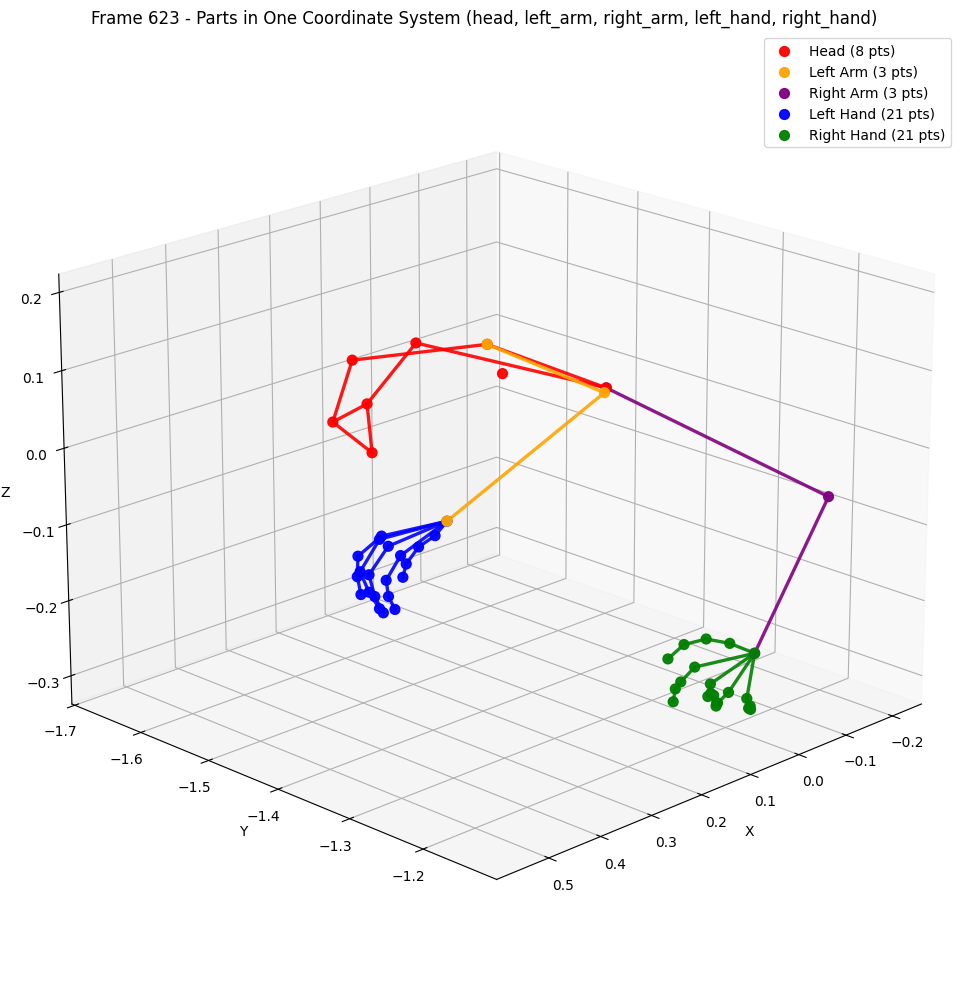

In [6]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/workspace/code')
from vis_3d_kpt.visualize import visualize_parts_in_one_coordinate

# 如果前面单元没运行，这里自动加载一帧数据
if 'info' not in globals():
    path = '/workspace/data/head3d_fuse_results/01/夜多い/smoothed_fused_npz/frame_000623_fused.npy'
    data = np.load(path, allow_pickle=True)
    info = data.item()

# 可选: 'head' 或 'head_arm_hand'
draw_mode = 'head_arm_hand'

save_path = Path('/workspace/code/logs/vis_3d_kpt/part_comparison.png')
fig, ax = visualize_parts_in_one_coordinate(
    points_3d=info['fused_keypoints_3d'],
    draw_option=draw_mode,
    title_prefix=f"Frame {info.get('frame_idx', '')}",
    save_path=save_path,
 )

print(f'✅ 已保存: {save_path}')
plt.show()
plt.close(fig)